In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression


In [2]:
df = load_data("College")
df

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [4]:
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [5]:
y = df["Apps"]
X = df.iloc[:, 2:]

X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=False)


In [6]:
# b)
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.score(X_test, y_test))

print(np.mean((lr.predict(X_test) - y_test) **2))

0.8693020288160888
1182113.666749982


In [7]:
# c)
scaler = StandardScaler()
# StandardScaler przeksztalca dane tak, aby kazda cecha miala srednia 0 i
# odchylenie standardowe = 1 czyli zwykly rozklad normalny (standardowy)

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

def ShrinkageMethod(method):
    model = method(alphas=np.linspace(.01, 100, 1000), cv=10)
    
    model.fit(X_train_sc, y_train)
    print("Metoda:", method)
    print("R2", model.score(X_test_sc, y_test))
    print("MSE :", np.mean((model.predict(scaler.transform(X_test)) - y_test) ** 2))

In [8]:
ShrinkageMethod(RidgeCV)

Metoda: <class 'sklearn.linear_model._ridge.RidgeCV'>
Acc 0.8754942834435625
MSE : 1126107.0680489794


In [9]:
ShrinkageMethod(LassoCV)

Metoda: <class 'sklearn.linear_model._coordinate_descent.LassoCV'>
Acc 0.8693078977526792
MSE : 1182060.584440516


In [10]:
# e, f) PCR - Principal Components Regression, PLS - Partial Least Squares

def DimReduction(method):
    max_val = 0
    max_comp = X_train.shape[1]
    scores_list = []
    for M in range(1, max_comp + 1):
        if method == "PCR":
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=M)),
                ("reg", LinearRegression())
            ])
        elif method == "PLS":
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("pls", PLSRegression(n_components=M))
            ])
        else:
            return 0
            
        scores = cross_val_score(model, X_train, y_train, cv=10, scoring="r2")
        scores_list.append(np.mean(scores))
        if np.mean(scores) > max_val:
            max_val = np.mean(scores)

    plt.plot(range(1, len(scores_list) + 1), scores_list, marker="o")
    plt.xlabel("Liczba komponentów")
    plt.ylabel("Średni R^2")
    plt.title(f"{method} - liczba komponentow")
    plt.show()
        
    print("Max R^2:", max_val)

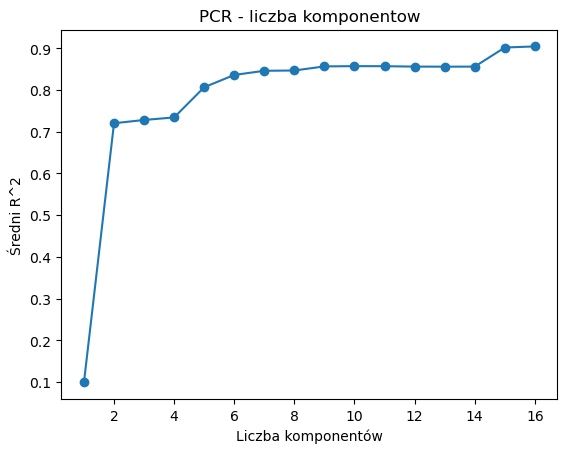

Max R^2: 0.9047046830225896


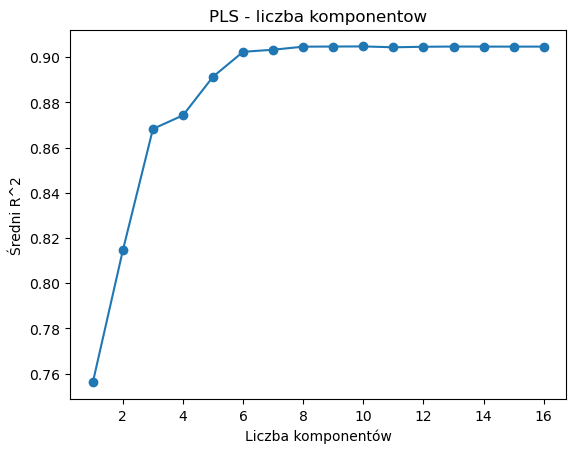

Max R^2: 0.9047820968953607


In [11]:
# e) PCR - Principal Components Regression
DimReduction("PCR")
DimReduction("PLS")

In [12]:
# g) Slightly difference, approx. ( 86% ~ 90% )